# 📈 Phân Tích Xu Hướng Thời Gian & Đặc Trưng — Hỗ Trợ Chia Train/Val/Test

**Mục tiêu:**
1. Visual PM2.5 theo **giờ, ngày, tháng** → Nhận diện mùa vụ, chu kỳ → Quyết định cắt train/val/test
2. Visual các đặc trưng trọng điểm: **Tiền chất (NO2, SO2, CO, O3), Nhiệt độ, Gió, Độ ẩm, Lượng mưa, Hướng gió**

**16 trạm được chọn:** `[1,2,3,4,5,6,7,16,17,18,24,27,28,30,31,32]`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SELECTED = [1,2,3,4,5,6,7,16,17,18,24,27,28,30,31,32]
NORTH = [1,2,3,4,5,6,16,17,27,28]
SOUTH = [7,18,24,30,31,32]

AIR_COLS = ['aqi','co','no2','o3','pm10','pm25','so2']
all_air = {}
all_weather = {}

for sid in SELECTED:
    df = pd.read_csv(f'data/raw/air/air_{sid}.csv')
    df['datetime'] = pd.to_datetime(df['timestamp_local'])
    df = df.set_index('datetime').sort_index()
    all_air[sid] = df[AIR_COLS].copy()
    
    dw = pd.read_csv(f'data/raw/weather/weather_{sid}.csv')
    dw.columns = [c.split(' (')[0].strip() for c in dw.columns]
    dw['datetime'] = pd.to_datetime(dw['time'])
    dw = dw.set_index('datetime').sort_index()
    all_weather[sid] = dw

info_map = {
    1:'Cầu Giấy',2:'Thanh Xuân',3:'Tây Hồ',4:'Thọ Xuân',5:'Gia Lâm',
    6:'Ba Vì',7:'Q1-HCM',16:'Đồ Sơn',17:'Hồng Bàng',18:'Ninh Kiều',
    24:'Biên Hòa',27:'Nam Định',28:'TP.Thanh Hóa',30:'Vĩnh Long',31:'Trà Vinh',32:'Rạch Giá'
}
print(f"Loaded {len(all_air)} stations")
print(f"Time range: {all_air[1].index.min()} → {all_air[1].index.max()}")


Loaded 16 stations
Time range: 2023-01-01 00:00:00 → 2025-12-01 00:00:00


## 1. 📅 PM2.5 — Toàn Bộ Dòng Thời Gian (Full Timeline)
Biểu đồ này cho thấy toàn bộ chuỗi PM2.5 daily từ đầu tới cuối. **Dùng để chọn điểm cắt Train/Val/Test.**


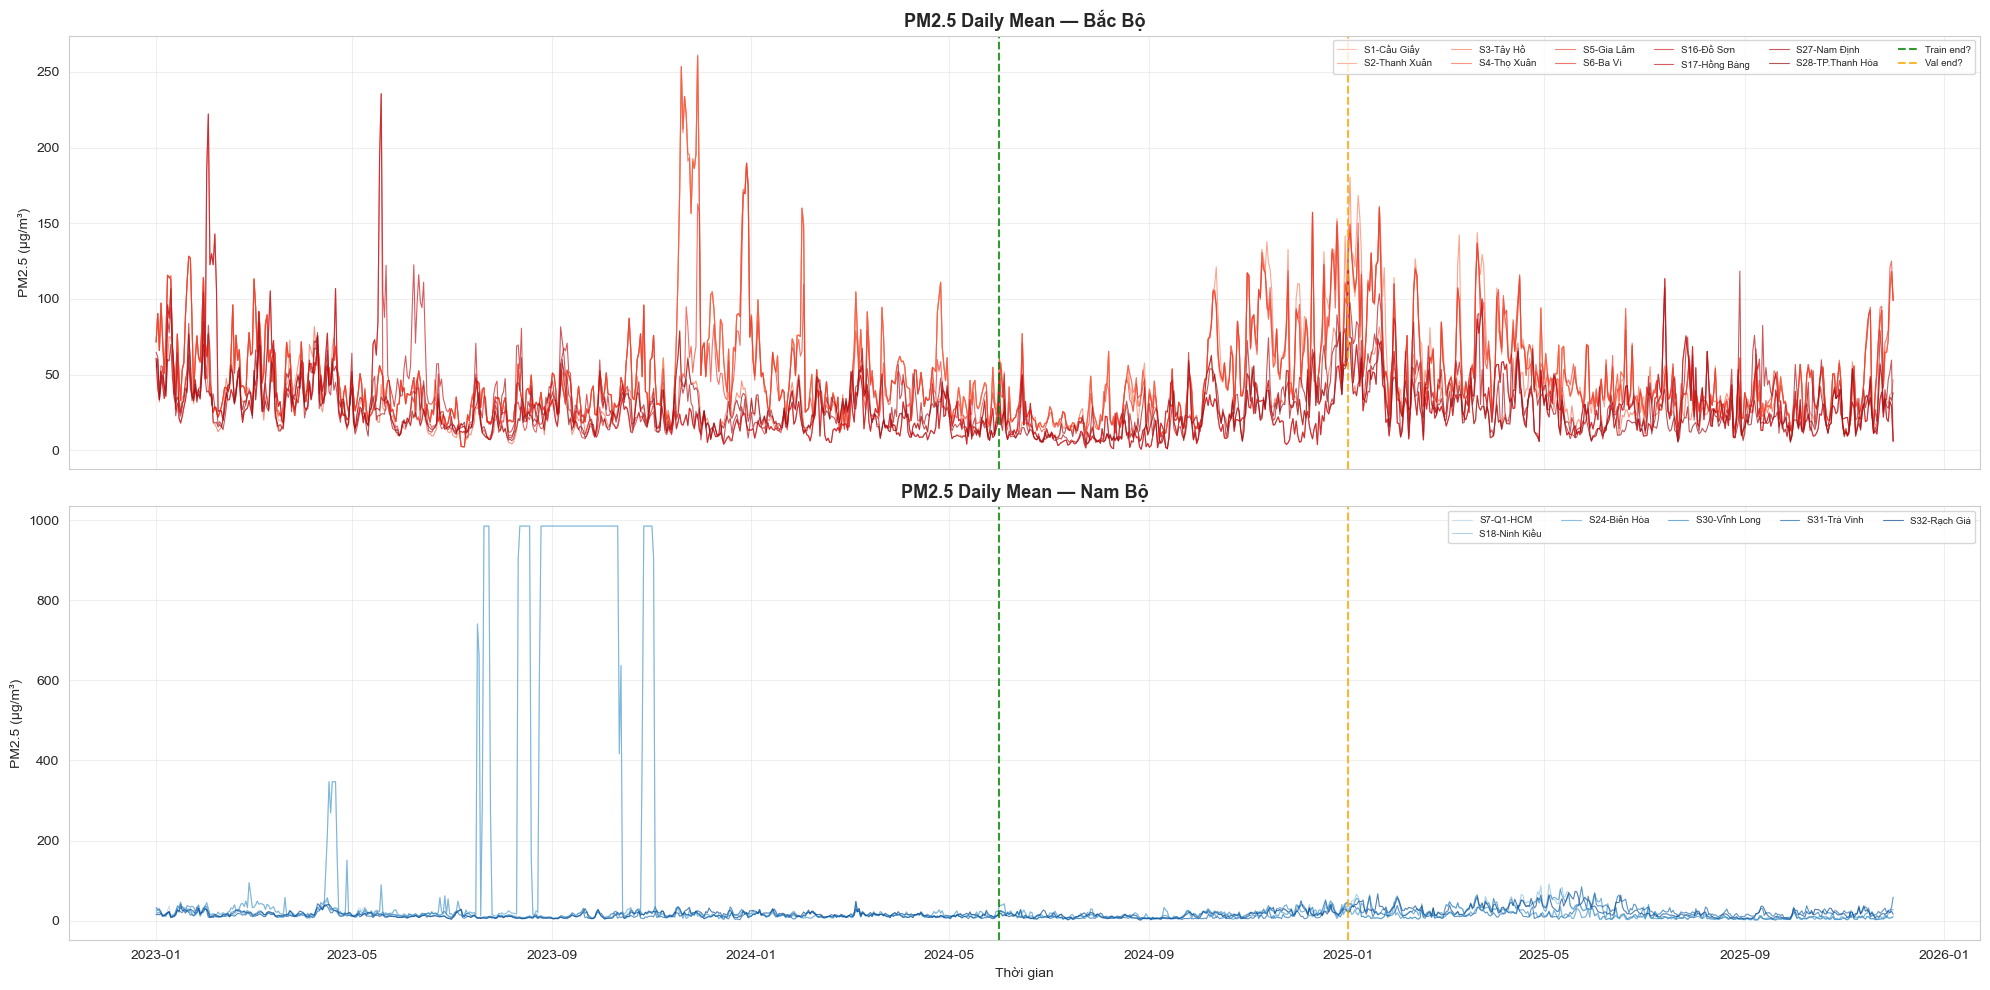

Gợi ý cắt: Train (2023-01 → 2024-06) | Val (2024-07 → 2024-12) | Test (2025-01 → cuối)


In [2]:
# === PM2.5 FULL TIMELINE — NORTH vs SOUTH ===
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        daily = all_air[sid]['pm25'].resample('D').mean()
        color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
        ax.plot(daily.index, daily.values, alpha=0.7, linewidth=0.8, 
                label=f"S{sid}-{info_map[sid]}", color=color)
    
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'PM2.5 Daily Mean — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7, ncol=5, loc='upper right')
    ax.grid(True, alpha=0.3)

# Mark potential train/val/test splits
for ax in axes:
    ax.axvline(pd.Timestamp('2024-06-01'), color='green', linestyle='--', alpha=0.8, label='Train end?')
    ax.axvline(pd.Timestamp('2025-01-01'), color='orange', linestyle='--', alpha=0.8, label='Val end?')

axes[0].legend(fontsize=7, ncol=6, loc='upper right')
plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()
print("Gợi ý cắt: Train (2023-01 → 2024-06) | Val (2024-07 → 2024-12) | Test (2025-01 → cuối)")


## 2. 📊 PM2.5 Theo Tháng — Seasonal Pattern
Boxplot cho thấy **mùa nào PM2.5 cao nhất** → Quan trọng khi chia data (nên đảm bảo mỗi split có đủ cả mùa cao + mùa thấp).


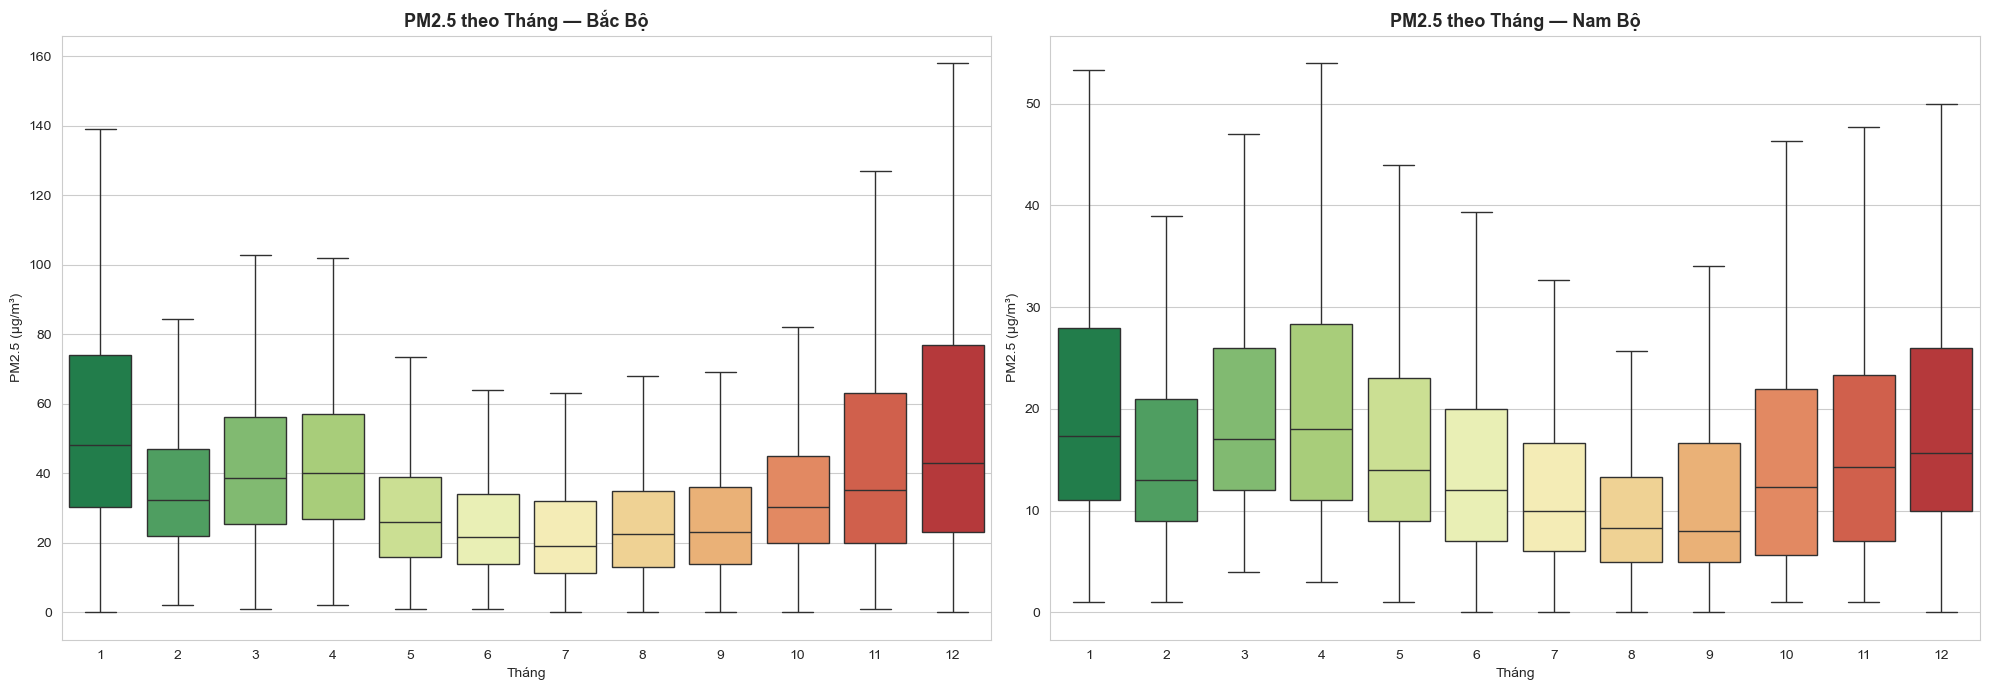

In [3]:
# === PM2.5 BY MONTH ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (label, ids) in zip(axes, [('Bắc Bộ', NORTH), ('Nam Bộ', SOUTH)]):
    frames = []
    for sid in ids:
        df = all_air[sid]['pm25'].to_frame()
        df['month'] = df.index.month
        df['station'] = f"S{sid}"
        frames.append(df)
    combined = pd.concat(frames)
    
    sns.boxplot(data=combined, x='month', y='pm25', ax=ax, 
                showfliers=False, palette='RdYlGn_r')
    ax.set_title(f'PM2.5 theo Tháng — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tháng')
    ax.set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()


## 3. ⏰ PM2.5 Theo Giờ Trong Ngày — Diurnal Pattern
Chu kỳ giờ cao điểm (rush hour) rất quan trọng cho model chuỗi thời gian.


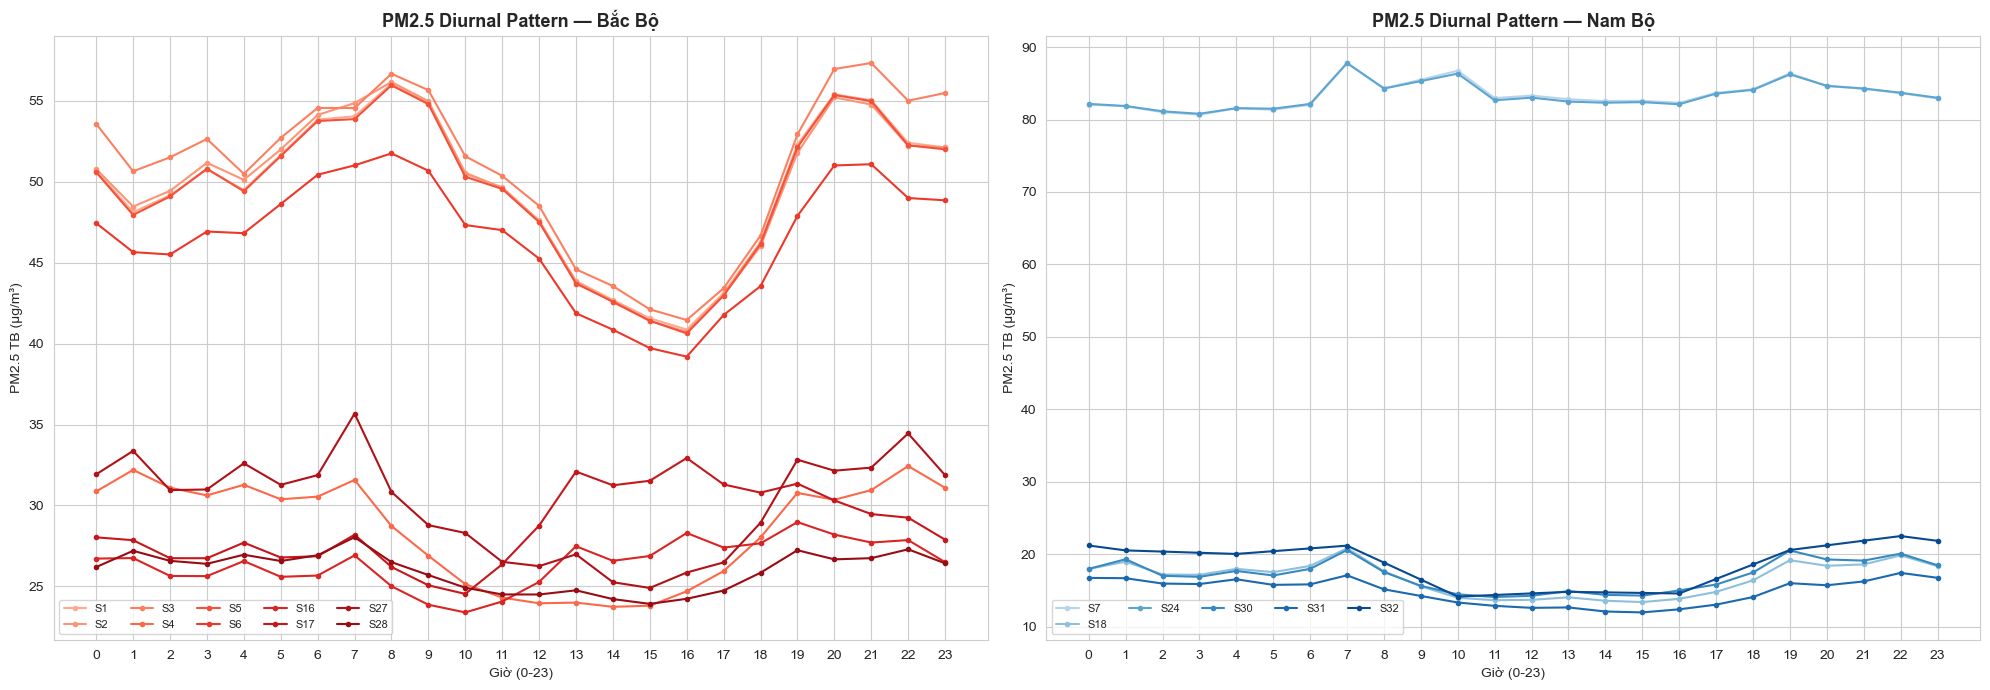

In [4]:
# === PM2.5 BY HOUR ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        hourly = all_air[sid]['pm25'].groupby(all_air[sid].index.hour).mean()
        color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
        ax.plot(hourly.index, hourly.values, marker='o', markersize=3, 
                label=f"S{sid}", color=color, linewidth=1.5)
    
    ax.set_xlabel('Giờ (0-23)')
    ax.set_ylabel('PM2.5 TB (µg/m³)')
    ax.set_title(f'PM2.5 Diurnal Pattern — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=5)
    ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()


## 4. 📆 PM2.5 Theo Ngày Trong Tuần
Kiểm tra xem cuối tuần có pattern khác ngày thường không (ảnh hưởng giao thông).


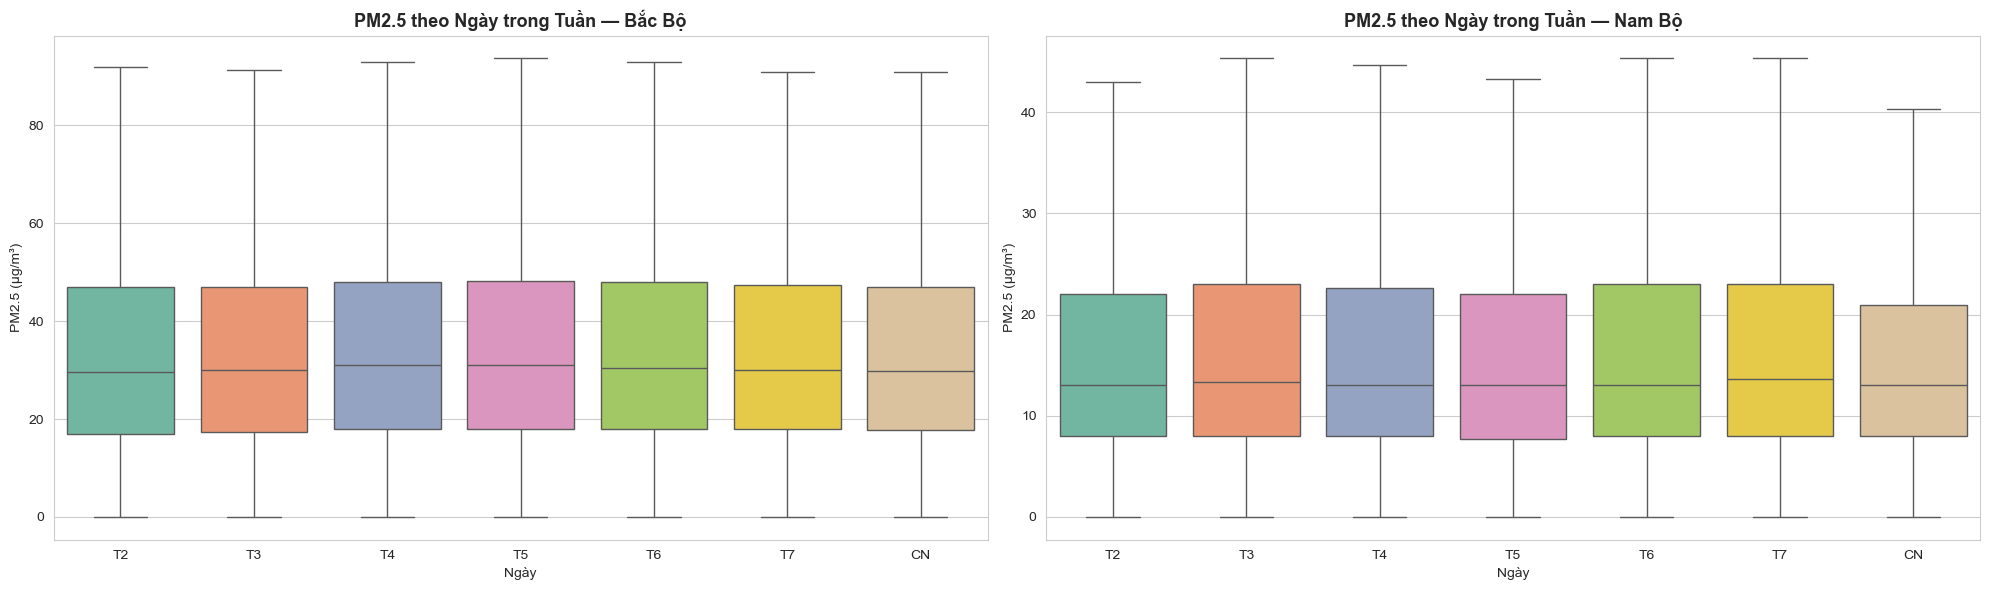

In [5]:
# === PM2.5 BY DAY OF WEEK ===
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
dow_labels = ['T2','T3','T4','T5','T6','T7','CN']

for ax, (label, ids) in zip(axes, [('Bắc Bộ', NORTH), ('Nam Bộ', SOUTH)]):
    frames = []
    for sid in ids:
        df = all_air[sid]['pm25'].to_frame()
        df['dow'] = df.index.dayofweek
        frames.append(df)
    combined = pd.concat(frames)
    
    sns.boxplot(data=combined, x='dow', y='pm25', ax=ax, 
                showfliers=False, palette='Set2')
    ax.set_xticklabels(dow_labels)
    ax.set_title(f'PM2.5 theo Ngày trong Tuần — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Ngày'); ax.set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()


## 5. 🧪 Tiền Chất Ô Nhiễm — NO2, SO2, CO, O3
Các tiền chất (Precursors) ảnh hưởng trực tiếp tới PM2.5. Visual theo tháng để thấy seasonal pattern.


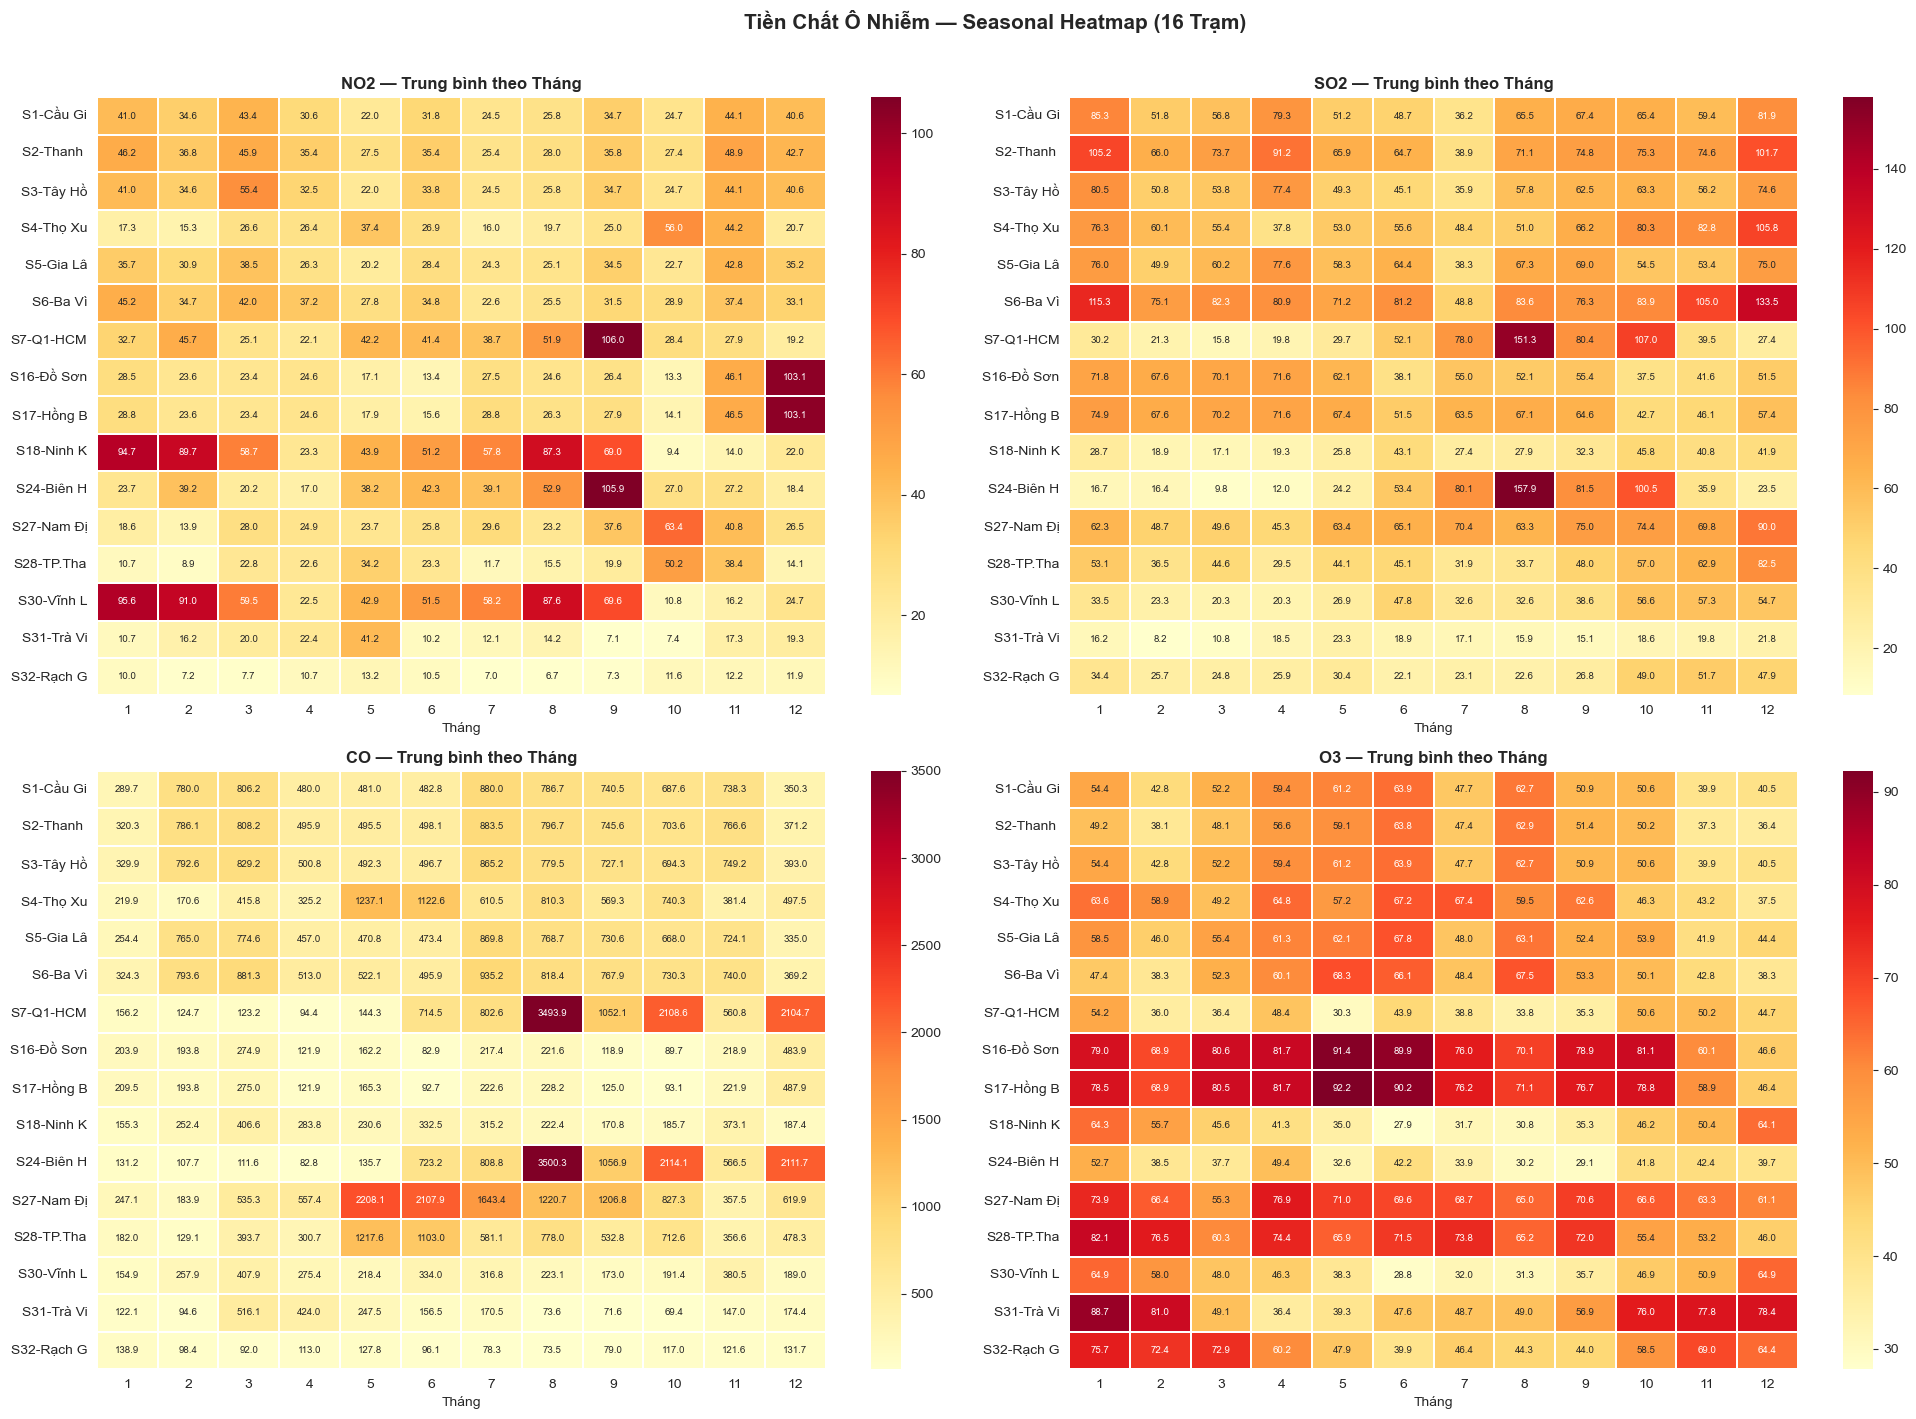

In [6]:
# === PRECURSOR MONTHLY HEATMAP ===
precursors = ['no2', 'so2', 'co', 'o3']

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, feat in zip(axes.flat, precursors):
    monthly = pd.DataFrame(index=SELECTED, columns=range(1,13), dtype=float)
    for sid in SELECTED:
        for month in range(1, 13):
            vals = all_air[sid][feat][all_air[sid].index.month == month]
            monthly.loc[sid, month] = vals.mean()
    
    monthly.index = [f"S{s}-{info_map[s][:6]}" for s in SELECTED]
    sns.heatmap(monthly.astype(float), annot=True, fmt='.1f', cmap='YlOrRd',
                ax=ax, linewidths=0.3, annot_kws={'size': 7})
    ax.set_title(f'{feat.upper()} — Trung bình theo Tháng', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tháng')

plt.suptitle('Tiền Chất Ô Nhiễm — Seasonal Heatmap (16 Trạm)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6. 🌡️ Nhiệt Độ — Seasonal & Daily Pattern


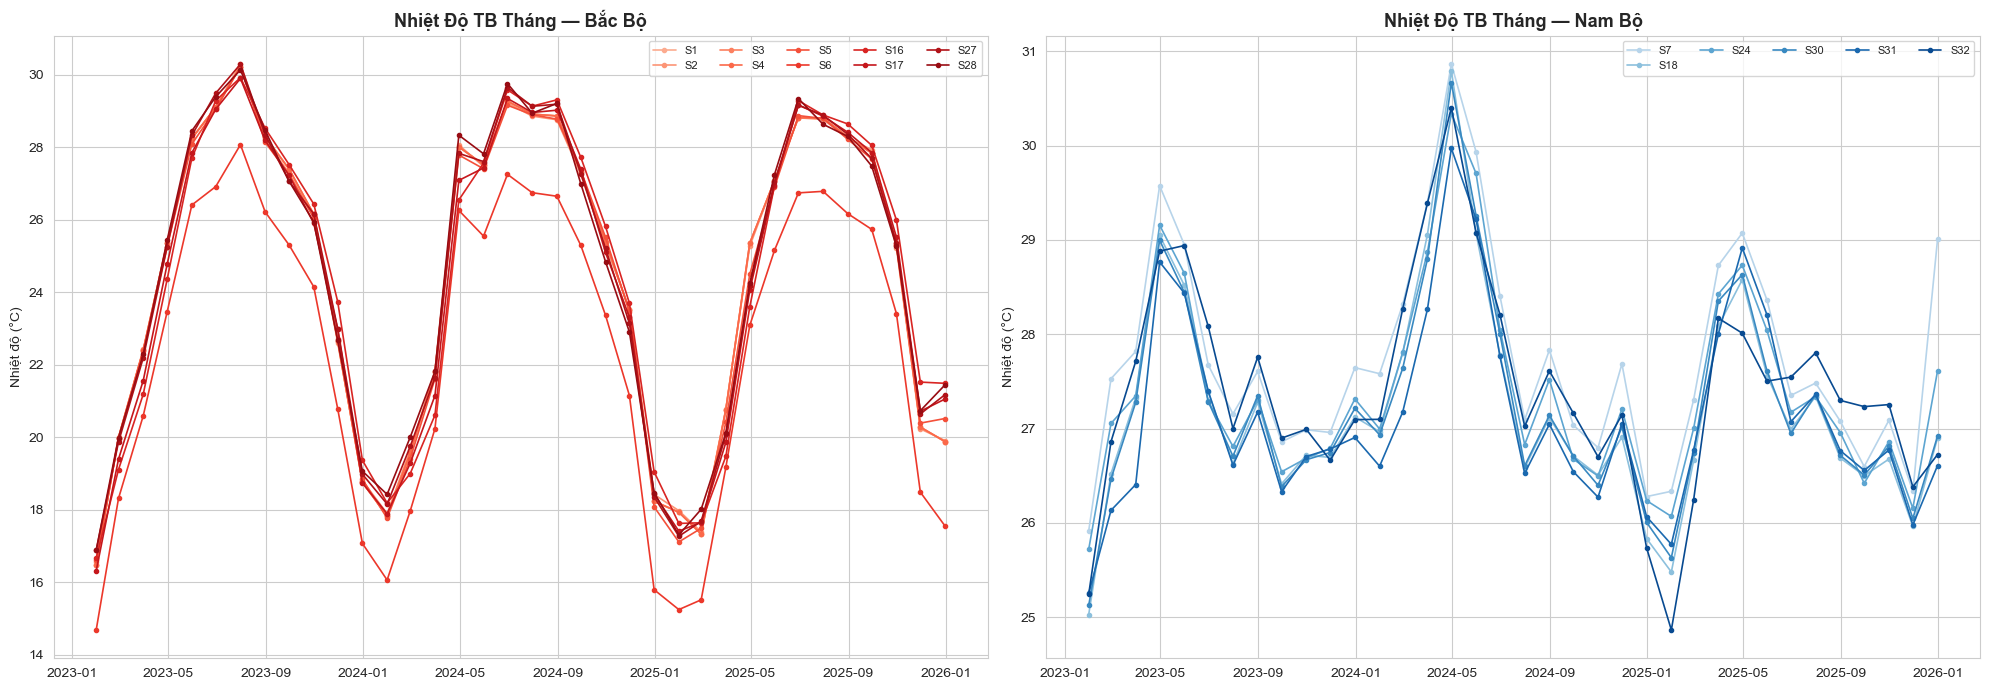

In [8]:
# === TEMPERATURE ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Monthly
for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        if 'temperature_2m' in all_weather[sid].columns:
            monthly = all_weather[sid]['temperature_2m'].resample('ME').mean()
            color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
            ax.plot(monthly.index, monthly.values, marker='o', markersize=3,
                    label=f"S{sid}", color=color, linewidth=1.2)
    ax.set_ylabel('Nhiệt độ (°C)')
    ax.set_title(f'Nhiệt Độ TB Tháng — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()


## 7. 💨 Tốc Độ Gió & Hướng Gió


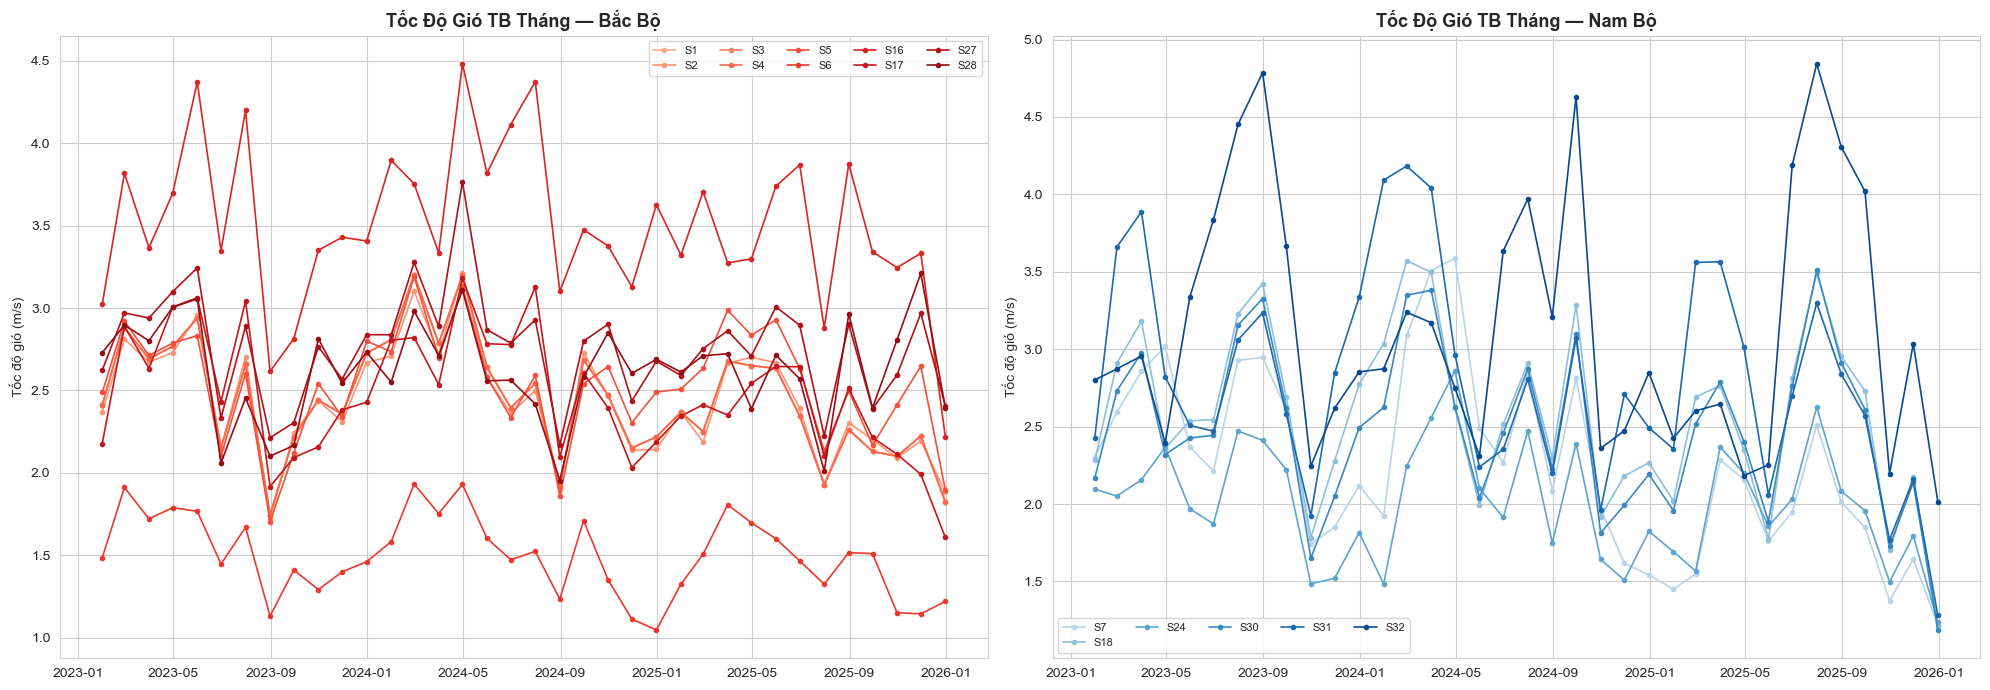

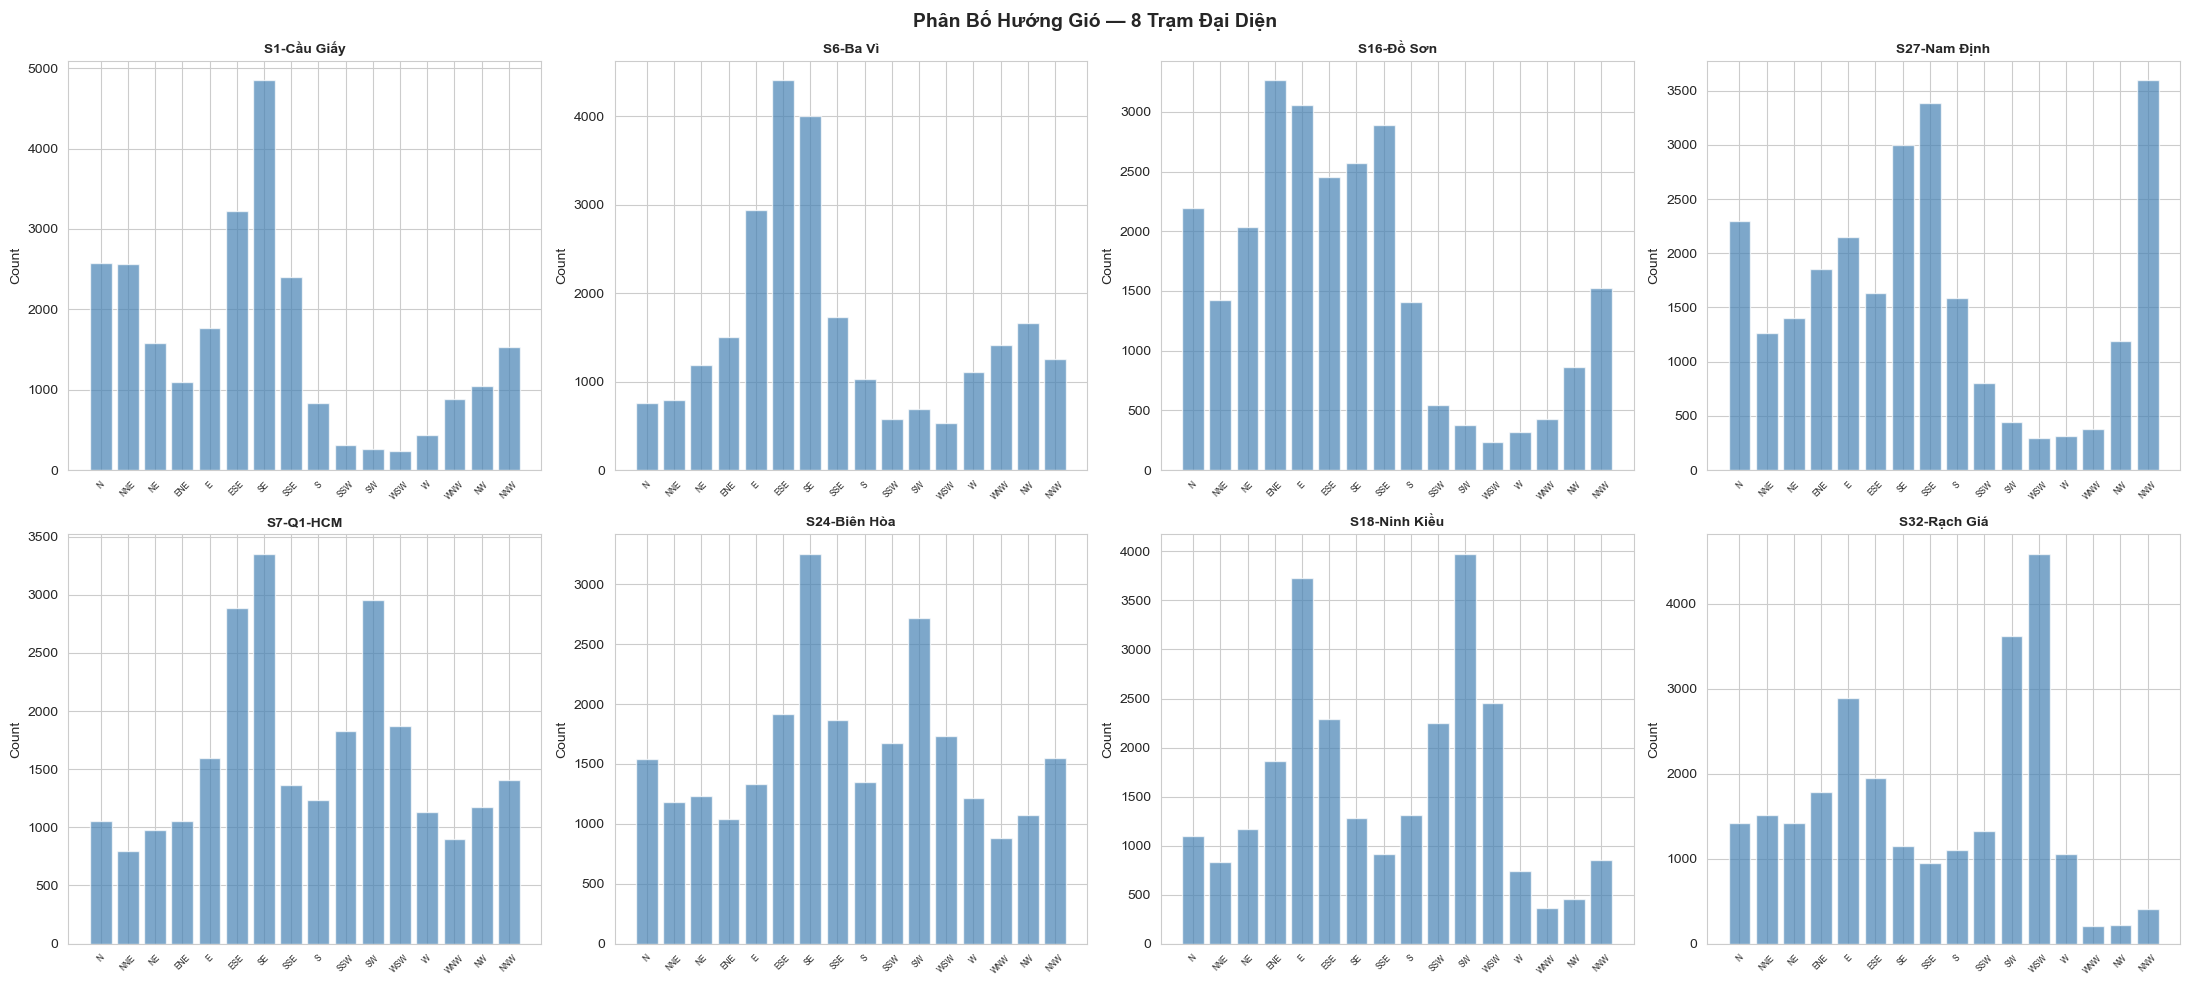

In [9]:
# === WIND SPEED MONTHLY ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        if 'wind_speed_10m' in all_weather[sid].columns:
            monthly = all_weather[sid]['wind_speed_10m'].resample('ME').mean()
            color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
            ax.plot(monthly.index, monthly.values, marker='o', markersize=3,
                    label=f"S{sid}", color=color, linewidth=1.2)
    ax.set_ylabel('Tốc độ gió (m/s)')
    ax.set_title(f'Tốc Độ Gió TB Tháng — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()

# === WIND ROSE (Direction distribution) ===
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
plot_stations = [1, 6, 16, 27, 7, 24, 18, 32]

for i, sid in enumerate(plot_stations):
    ax = axes[i]
    if 'wind_direction_10m' in all_weather[sid].columns:
        wd = all_weather[sid]['wind_direction_10m'].dropna()
        bins = np.arange(0, 361, 22.5)
        hist, _ = np.histogram(wd, bins=bins)
        directions = ['N','NNE','NE','ENE','E','ESE','SE','SSE','S','SSW','SW','WSW','W','WNW','NW','NNW']
        ax.bar(range(16), hist, color='steelblue', alpha=0.7)
        ax.set_xticks(range(16))
        ax.set_xticklabels(directions, fontsize=6, rotation=45)
        ax.set_title(f'S{sid}-{info_map[sid]}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Count')

plt.suptitle('Phân Bố Hướng Gió — 8 Trạm Đại Diện', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. 💧 Độ Ẩm Tương Đối


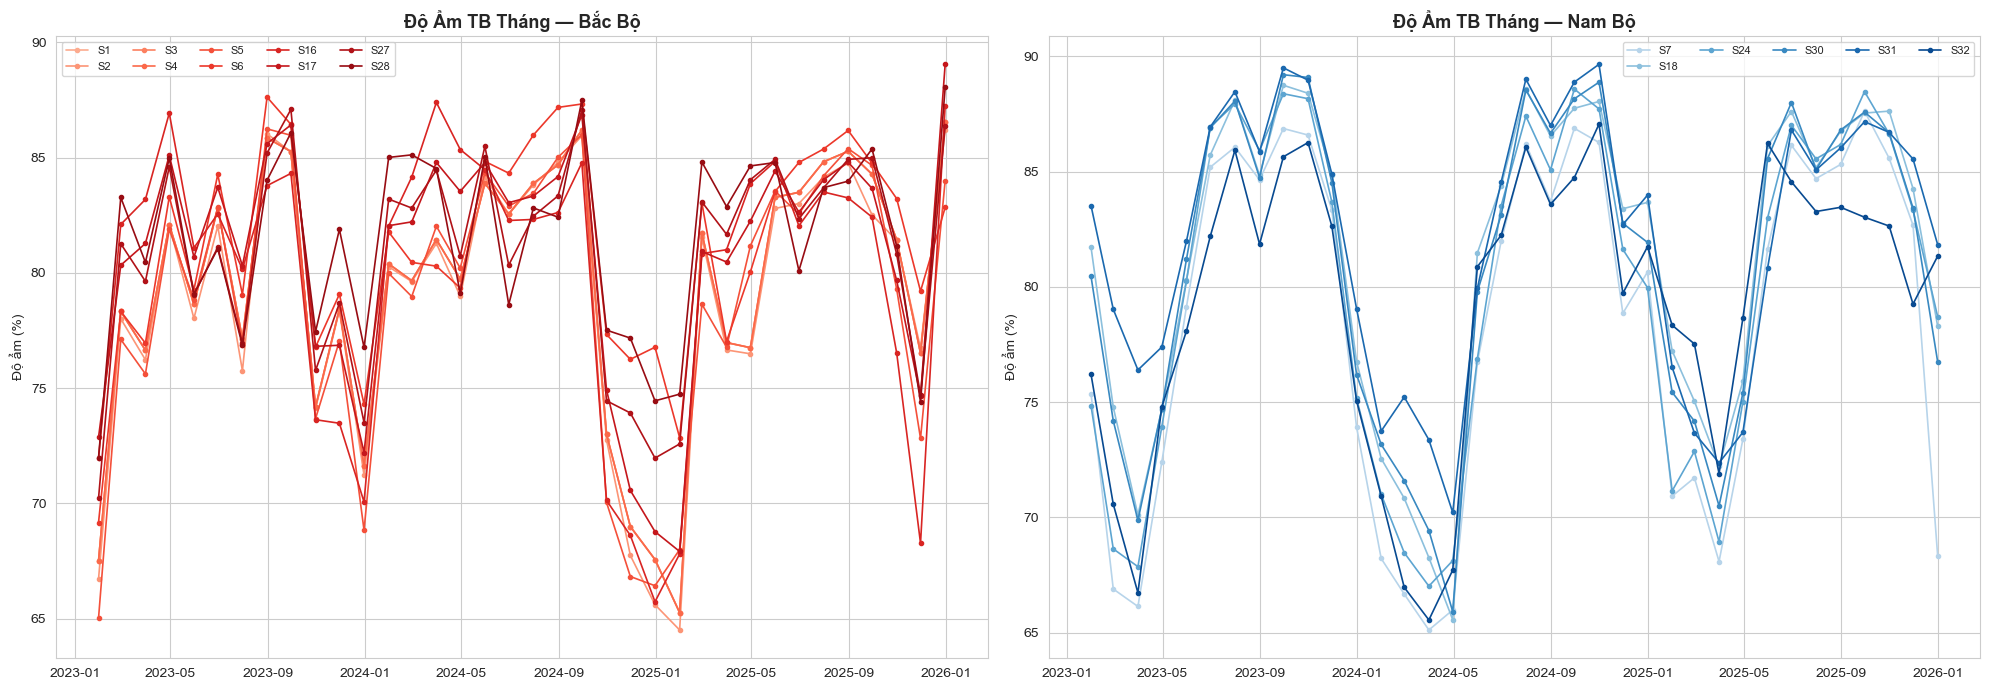

In [11]:
# === HUMIDITY ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        if 'relative_humidity_2m' in all_weather[sid].columns:
            monthly = all_weather[sid]['relative_humidity_2m'].resample('ME').mean()
            color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
            ax.plot(monthly.index, monthly.values, marker='o', markersize=3,
                    label=f"S{sid}", color=color, linewidth=1.2)
    ax.set_ylabel('Độ ẩm (%)')
    ax.set_title(f'Độ Ẩm TB Tháng — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()


## 9. 🌧️ Lượng Mưa


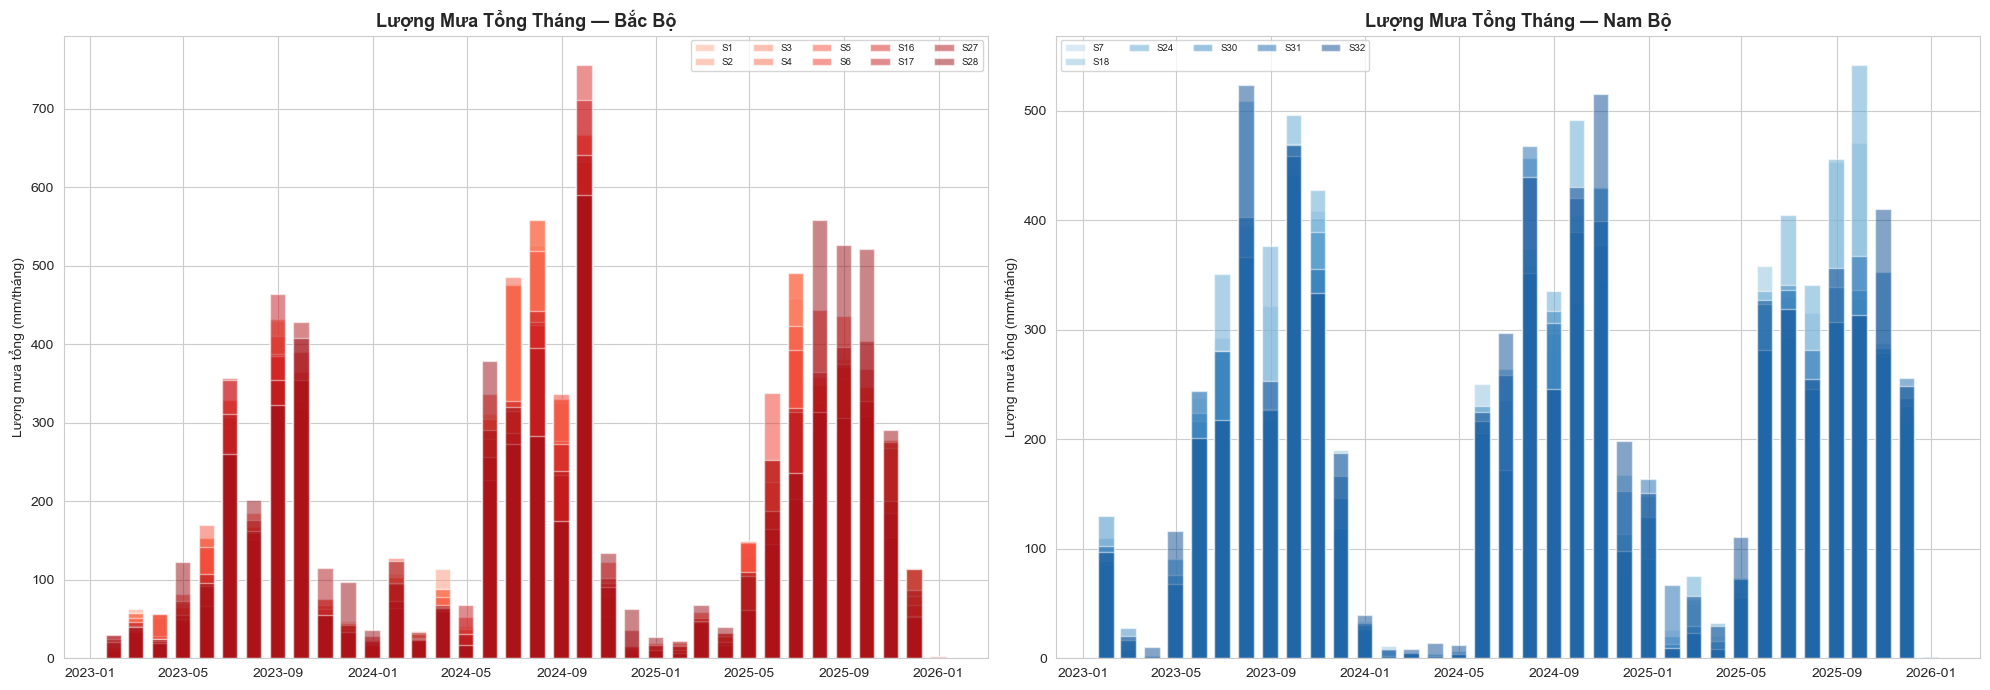

In [12]:
# === PRECIPITATION ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, (label, ids, cmap_name) in zip(axes, [('Bắc Bộ', NORTH, 'Reds'), ('Nam Bộ', SOUTH, 'Blues')]):
    cmap = plt.get_cmap(cmap_name)
    for i, sid in enumerate(ids):
        if 'precipitation' in all_weather[sid].columns:
            monthly = all_weather[sid]['precipitation'].resample('ME').sum()
            color = cmap(0.3 + 0.6 * i / max(len(ids)-1, 1))
            ax.bar(monthly.index, monthly.values, width=20, alpha=0.5,
                   label=f"S{sid}", color=color)
    ax.set_ylabel('Lượng mưa tổng (mm/tháng)')
    ax.set_title(f'Lượng Mưa Tổng Tháng — {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7, ncol=5)

plt.tight_layout()
plt.show()


## 10. ✂️ Phân Tích Chia Train / Val / Test
Dựa trên các pattern đã phân tích ở trên, dưới đây là các phương án chia data:


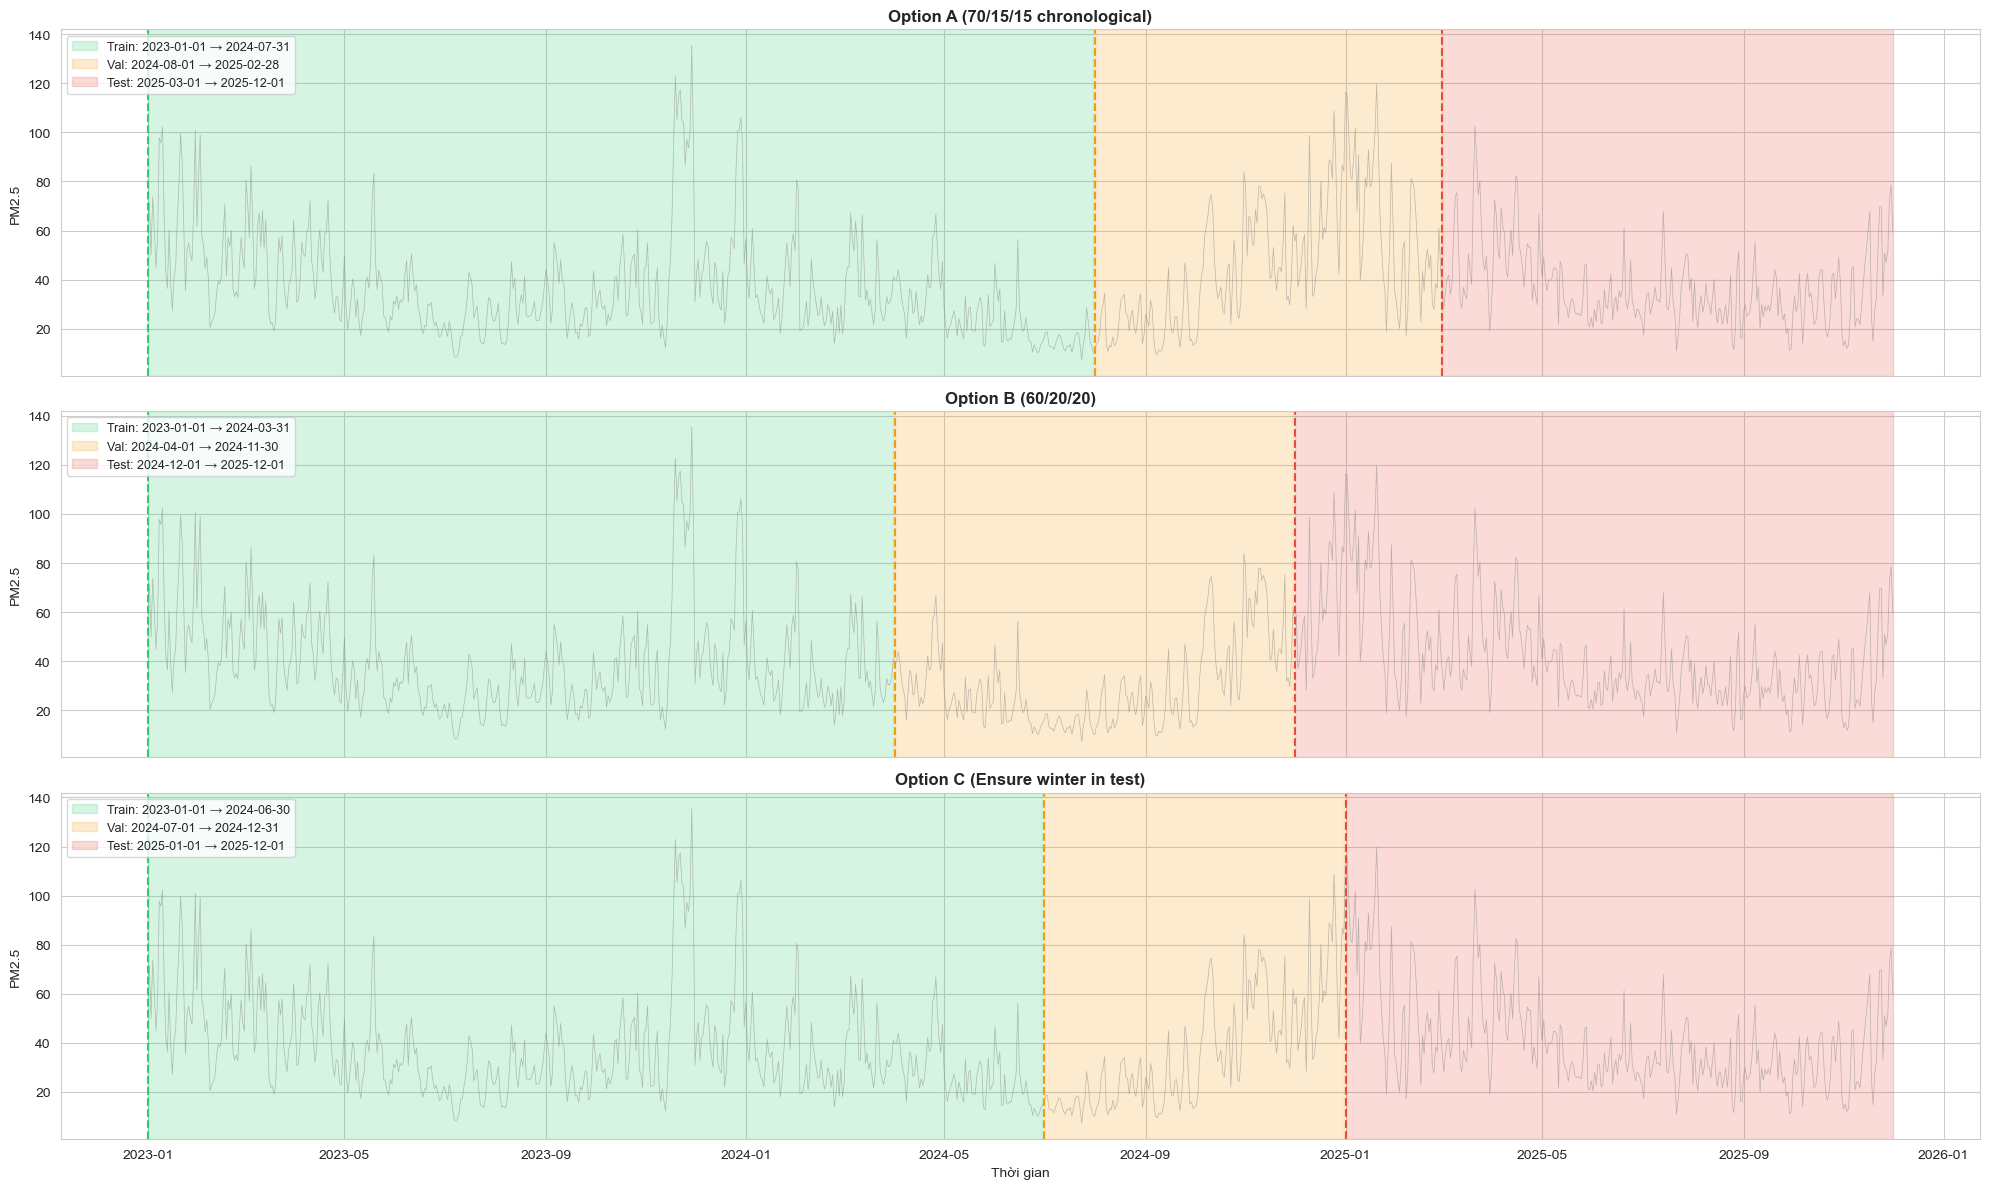


=== THỐNG KÊ PM2.5 THEO TỪNG PHƯƠNG ÁN CHIA ===

Option A (70/15/15 chronological):


ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [13]:
# === TRAIN/VAL/TEST SPLIT OPTIONS ===

splits = {
    'Option A (70/15/15 chronological)': {
        'Train': ('2023-01-01', '2024-07-31'),
        'Val':   ('2024-08-01', '2025-02-28'),
        'Test':  ('2025-03-01', '2025-12-01')
    },
    'Option B (60/20/20)': {
        'Train': ('2023-01-01', '2024-03-31'),
        'Val':   ('2024-04-01', '2024-11-30'),
        'Test':  ('2024-12-01', '2025-12-01')
    },
    'Option C (Ensure winter in test)': {
        'Train': ('2023-01-01', '2024-06-30'),
        'Val':   ('2024-07-01', '2024-12-31'),
        'Test':  ('2025-01-01', '2025-12-01')
    }
}

# Visualize each option
fig, axes = plt.subplots(len(splits), 1, figsize=(20, 4*len(splits)), sharex=True)

colors_split = {'Train': '#2ecc71', 'Val': '#f39c12', 'Test': '#e74c3c'}

for ax, (name, periods) in zip(axes, splits.items()):
    pm_north = pd.concat([all_air[s]['pm25'] for s in NORTH]).resample('D').mean()
    ax.plot(pm_north.index, pm_north.values, color='gray', alpha=0.5, linewidth=0.5)
    
    for split_name, (start, end) in periods.items():
        s, e = pd.Timestamp(start), pd.Timestamp(end)
        ax.axvspan(s, e, alpha=0.2, color=colors_split[split_name], label=f'{split_name}: {start} → {end}')
        ax.axvline(s, color=colors_split[split_name], linestyle='--', linewidth=1.5)
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('PM2.5')
    ax.legend(fontsize=9, loc='upper left')

plt.xlabel('Thời gian')
plt.tight_layout()
plt.show()

# Statistics per split
print("\n=== THỐNG KÊ PM2.5 THEO TỪNG PHƯƠNG ÁN CHIA ===")
for name, periods in splits.items():
    print(f"\n{name}:")
    for split_name, (start, end) in periods.items():
        s, e = pd.Timestamp(start), pd.Timestamp(end)
        vals = []
        for sid in SELECTED:
            v = all_air[sid]['pm25'].loc[s:e].dropna()
            vals.extend(v.values)
        vals = np.array(vals)
        months = pd.date_range(s, e, freq='M').month.unique()
        print(f"  {split_name:5s}: {s.strftime('%Y-%m-%d')} → {e.strftime('%Y-%m-%d')} | "
              f"N={len(vals):,} | mean={vals.mean():.1f} | std={vals.std():.1f} | "
              f"months={sorted(months.tolist())}")
